# Pre-Processing

## Unzipping Raw `.zip` Files

In [1]:
import os
import zipfile

def unzip_pdir(
    src_filepath:str,       # The input zip file
    out_dirpath:str = None  # Where do we save the files?
):
    # Prepare outpath
    if out_dirpath is None: 
        out_dirpath = os.path.dirname(src_filepath)
    
    # Ensure that the outpath exists
    os.makedirs(out_dirpath, exist_ok=True)

    # Read archive
    with zipfile.ZipFile(src_filepath) as archive:
        names = archive.namelist()

        # Account for Mac OS X
        def is_valid(name:str):
            return not (
                name.startswith('_MACOSX') or
                os.path.basename(name).startswith("._")
            )
        valid_names = [n for n in names if is_valid(n)]

        # Detect common to-level folder
        top_levels = [name.split('/')[0] for name in valid_names if name.strip()]
        common_root = None 
        if len(set(top_levels)) == 1:
            common_root = top_levels[0]

        for _file in valid_names:
            target = _file
            # Strip the common root folder, if it exists
            if common_root:
                parts = _file.split('/', 1)
                if len(parts) > 1: 
                    target = parts[1]
                else:
                    continue
            if not target:
                continue

            target_path = os.path.join(out_dirpath, target)

            # Create directories as needed
            os.makedirs(os.path.dirname(target_path), exist_ok=True)

            if not _file.endswith('/'):
                with archive.open(_file) as source, open(target_path, 'wb') as dest:
                    dest.write(source.read())


In [2]:
participants = [
    'P1',
    'P2',
    'P3',
    'P4',
    'P5',
    'P6',
    'P7',
    'P8',
    'P9', 
    'P10',
    'P13',
    'PI1',
    'PI2'
]

for p in participants:
    unzip_pdir(f'./data/raws/{p}.zip', out_dirpath=f'./data/processed/{p}')
#unzip_pdir('./data/raws/P2.zip', out_dirpath='./data/processed/P2')
#unzip_pdir('./data/raws/P3.zip', out_dirpath='./data/processed/P3')
#unzip_pdir('./data/raws/P4.zip', out_dirpath='./data/processed/P4')
#unzip_pdir('./data/raws/P5.zip', out_dirpath='./data/processed/P5')
#unzip_pdir('./data/raws/P6.zip', out_dirpath='./data/processed/P6')
#unzip_pdir('./data/raws/P7.zip', out_dirpath='./data/processed/P7')
#unzip_pdir('./data/raws/P8.zip', out_dirpath='./data/processed/P8')
#unzip_pdir('./data/raws/P9.zip', out_dirpath='./data/processed/P9')
#unzip_pdir('./data/raws/P10.zip', out_dirpath='./data/processed/P10')
#unzip_pdir('./data/raws/P13.zip', out_dirpath='./data/processed/P13')
#unzip_pdir('./data/raws/PI1.zip', out_dirpath='./data/processed/PI1')
#unzip_pdir('./data/raws/PI2.zip', out_dirpath='./data/processed/PI2')

## Extracting Timestamps

In [3]:
import pandas as pd
import os

def timestamps(
    filepath:str,
    ts_colname:str = 'unix_ms',
    frame_colname:str = 'frame',
    outpath:str = None
):
    """
    Given the eye data (or some file with trial-length timestamps and frames),
    Generate a new DataFrame purely containing timestamps.
    - Returns:
        The timestamp dataframe
    """
    df = pd.read_csv(filepath)
    df = df[[ts_colname, frame_colname]]
    if outpath is not None:
        outdir = os.path.split(outpath)[0]
        os.makedirs(outdir, exist_ok=True)
        df.to_csv(outpath, index=False)
    return df

In [4]:
for p in participants:
    timestamps(f'./data/processed/{p}/eye.csv', outpath=f'./data/processed/{p}/timestamps.csv')

## Combine Calibration Files

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

def find_files_by_pattern(src_dir:str, pattern:str="*.csv"):
    """ 
    Given a directory, use glob.glob to recursively search for any files matching a provided pattern.
    """
    return sorted(glob.glob(os.path.join(src_dir, pattern)))

_CALIBRATION_COLUMNS = [
    'unix_ms', 
    'frame', 
    'rel_timestamp',
    'event', 
    'overlap_counter'
]

def handle_cal_file(_F:str):
    """ 
    Assuming `_F` is a calibration file, read it, correct it, and return it as a DataFrame
    - Returns: A Pandas DataFrame
    """
    # Reading the DF
    df = pd.read_csv(_F)                            # Read the file
    df = df.iloc[:, :len(_CALIBRATION_COLUMNS)]     # Correction
    df.columns = _CALIBRATION_COLUMNS               # Apply new columns
    # Adding new columns
    fname = os.path.splitext(os.path.split(_F)[1])[0]
    cid = fname.split('_')[-1]
    if not cid.isdigit(): cid = 0
    df['trial_id'] = cid
    # Reorganize column names
    df = df.loc[:, ['trial_id']+_CALIBRATION_COLUMNS]
    # Return new dataframe
    return df

def combine_calibration_files(
    src_dir:str,
    pattern:str = 'calibration_*.csv',
    outpath:str = None
):
    """ 
    Given a participant's directory, identify and concatenate all 
    calibration files.
    - Returns:  
        The concatenated dataframe of all calibration data
    """
    files = find_files_by_pattern(src_dir, pattern=pattern)
    dfs = [handle_cal_file(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)
    if outpath is not None:
        outdir = os.path.split(outpath)[0]
        os.makedirs(outdir, exist_ok=True)
        df.to_csv(outpath, index=False)
    return df

def plot_calibrations(
    tdf, 
    cdf, 
    tdf_colname:str='unix_ms', 
    cdf_colname:str='unix_ms',
    outpath:str=None
):
    """ 
    --- Collect first timestamps from calibration files ---
    """

    # Extract timestamps
    x = tdf[tdf_colname].to_numpy()
    _y = cdf[[cdf_colname, 'event', 'trial_id']]
    y = _y[_y['event']=='Start']

    # Start, end, and trial start times
    start_time = x.min()
    end_time = x.max()
    markers = [(f"Trial {i}:\n{t}", t) for t,i in zip(y[cdf_colname],y['trial_id'])]

    # --- Plot ---
    plt.figure(figsize=(10, 4))
    plt.plot(x, [0]*len(x), alpha=0.2, label="VR time")

    # Add vertical markers for each smaller file
    for name, t in markers:
        plt.axvline(x=t, color='red', linestyle='--', alpha=0.7)
        plt.text(t, 0.1, name, rotation=90, verticalalignment='bottom', fontsize=8)

    # Add a vertical marker for the start and ends too.
    plt.axvline(x=start_time, color='blue', linestyle='--', alpha=0.7)
    plt.text(start_time, 0.1, f"Eye Start\n{start_time}", rotation=90, verticalalignment='bottom', fontsize=7.5)

    # Render other stuff
    plt.xlim(start_time, end_time)
    plt.xlabel(tdf_colname)
    plt.yticks([])
    plt.title(f"Timeline of Eye Data to Calibrations:")
    plt.legend()
    plt.tight_layout()
    if outpath is not None:        
        outdir, outname = os.path.split(outpath)
        os.makedirs(outdir, exist_ok=True)
        plt.savefig(outpath, bbox_inches="tight", dpi=300)
    plt.show()


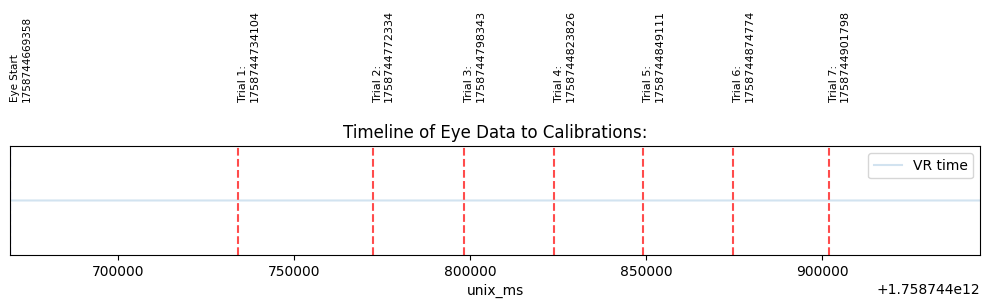

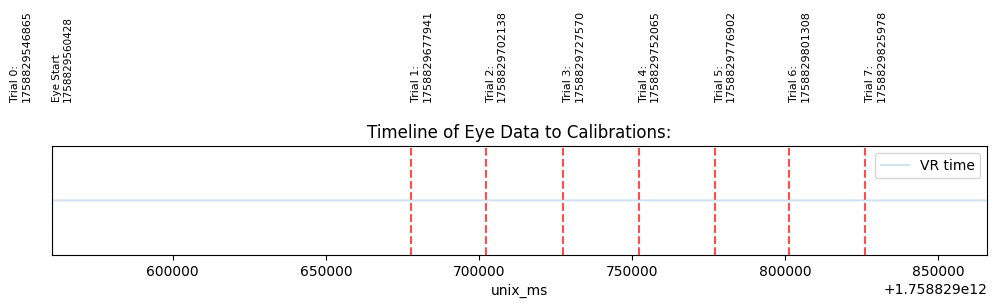

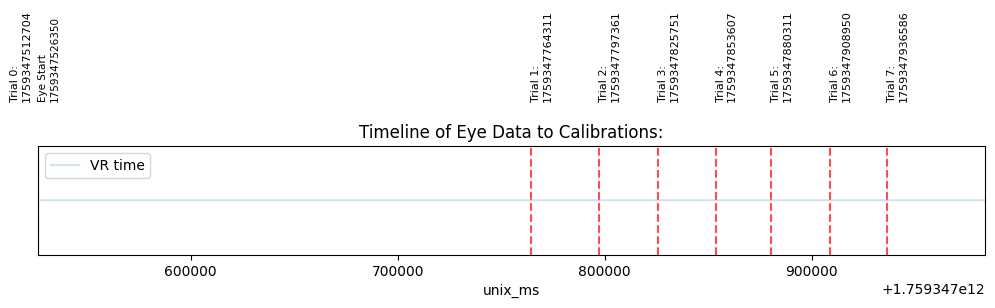

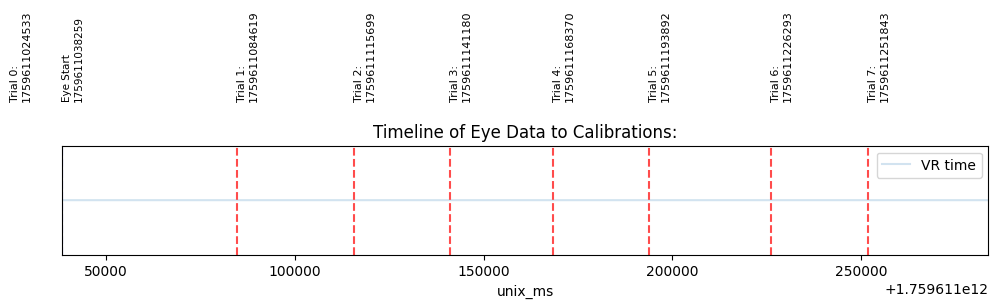

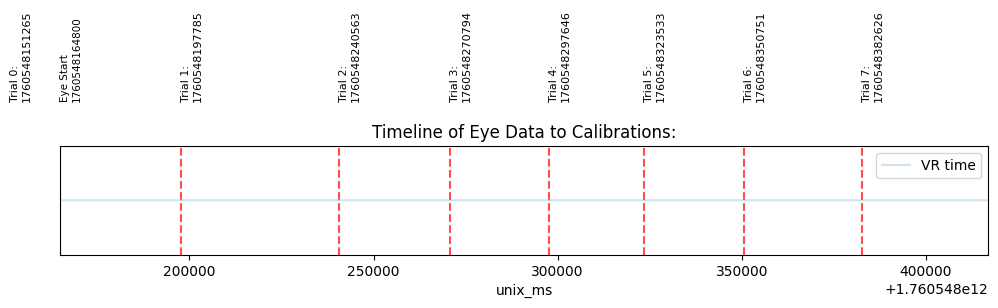

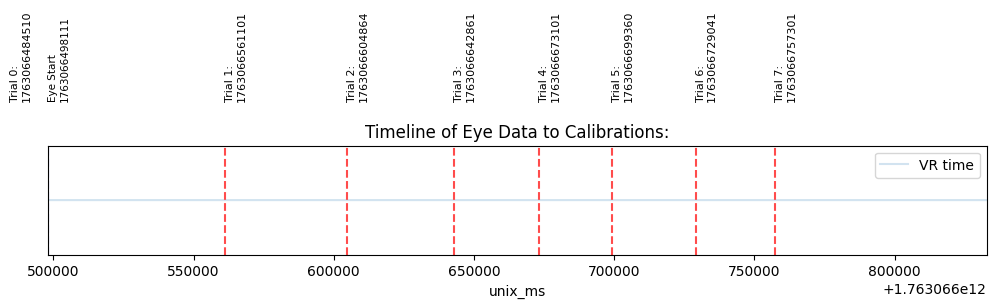

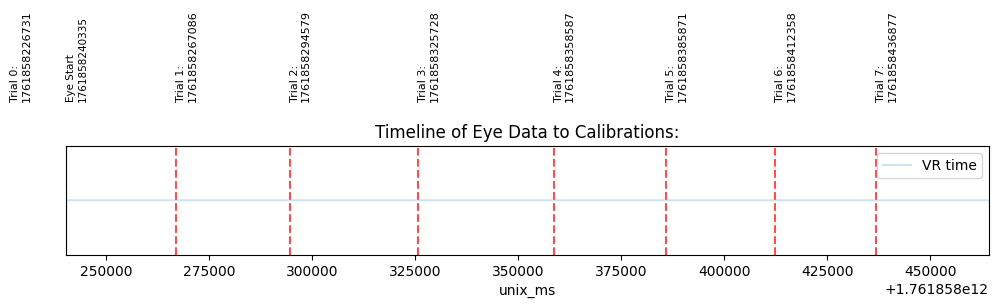

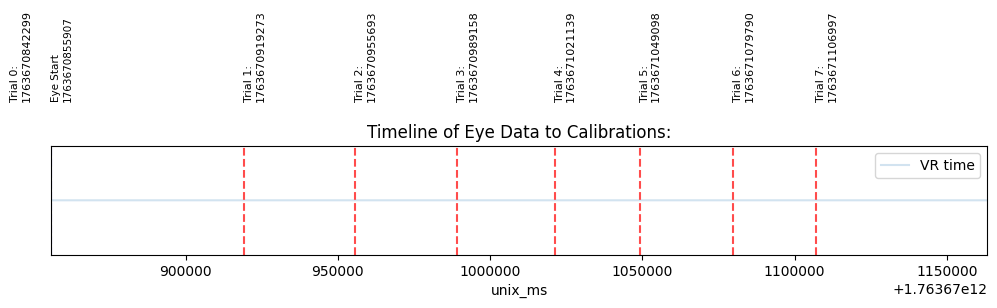

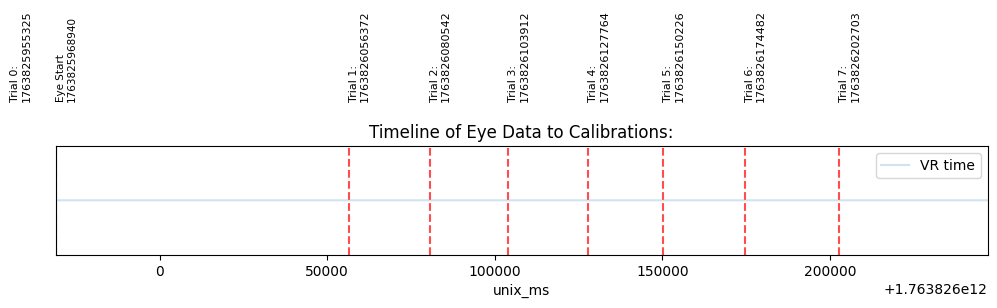

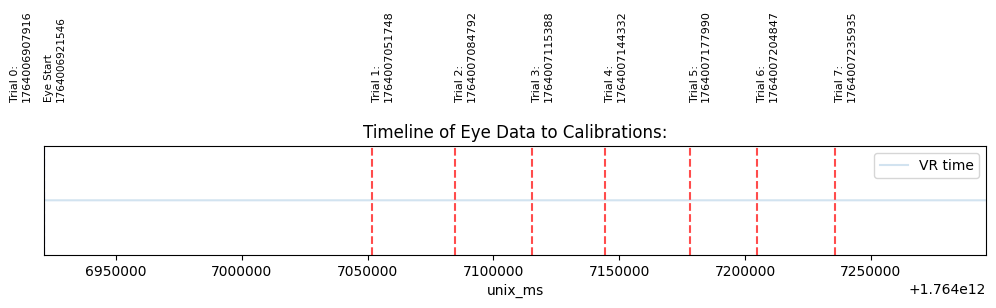

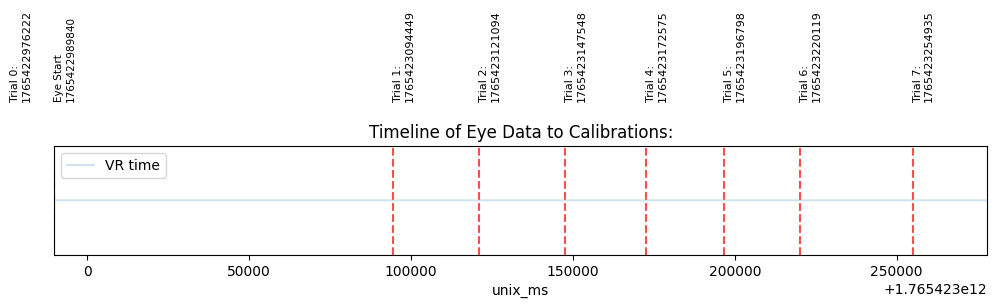

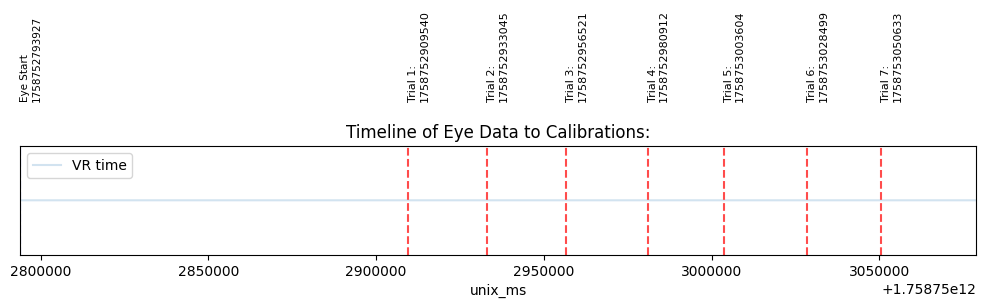

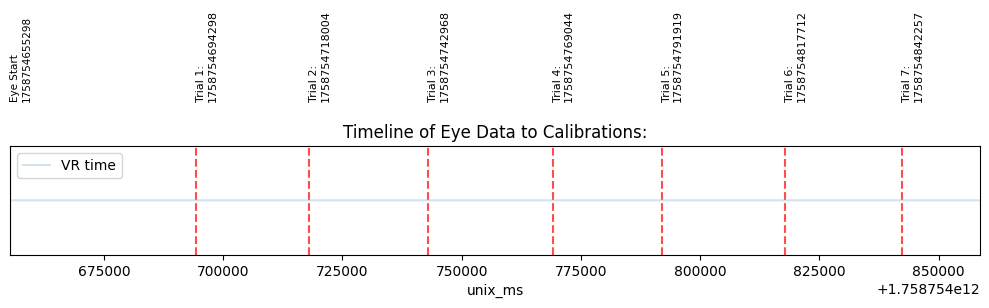

In [17]:
for p in participants:
    # Calibration df
    cdf_path = f'./data/processed/{p}/calibration.csv'
    if not os.path.exists(cdf_path):    cdf = combine_calibration_files(f'./data/processed/{p}', outpath=cdf_path)
    else:                               cdf = pd.read_csv(cdf_path)
    # Timestamp df
    tdf_path = f'./data/processed/{p}/timestamps.csv'
    if not os.path.exists(tdf_path):    tdf = timestamps(f'./data/processed/{p}/eye.csv', outpath=tdf_path)
    else:                               tdf = pd.read_csv(tdf_path)
    # Plot calibrations
    plot_calibrations(tdf, cdf, outpath=f'./data/processed/{p}/plots/calibration.png')

## Finalizing EEG Files

In [ ]:
from typing import Union
from RecordMuse.processing.filter import filter_eeg
from RecordMuse.processing.normalize import normalize
from RecordMuse.analysis.psd import calculate_psd

def validate_eeg_format(
    eeg_src:str
):



def eeg(
    rest_filepath:str,
    sim_filepath:str,
    apply_bandpass:bool = True,
    ts_colname:str = 'lsl_unix_ts',
    start_buffer:Union[int,float] = 5.0,
    end_buffer:Union[int,float] = 5.0,
    validate:bool = True
):
    # Filter the rest EEG to ensure no weird spikes in data
    # By default, saves the file as `EEG_filtered.csv`
    rest_f_filepath = filter_eeg(rest_filepath, apply_bandpass=apply_bandpass)
    # Filter the simulation EEG for the same reason
    sim_f_filepath = filter_eeg(sim_fileapth, apply_bandpass=apply_bandpass)
    # Using the rest EEG, normalize the simulation EEG
    """
    normalized_filepath = normalize(
        rest_f_filepath, 
        sim_f_filepath, 
        ts_col=ts_colname, 
        start_buffer=start_buffer, 
        end_buffer=end_buffer,
        validate=validate_normalization
    )
    # Caluclate the PSD given the normalized filepath
    calculate_psd(normalized_filepath)
    """
    

In [20]:
for p in participants:
    eeg(
        f'./data/processed/{p}/eeg_rest.csv',
        f'./data/processed/{p}/eeg_vr.csv',
    )
    

Loading EEG file: data/processed/P1/eeg_rest.csv


ValueError: Missing EEG channel: TP9